# Probabilistic Model Using VED

This model generates **synthetic defect data from the VED**.

Many specimens, each with a varying number of different defects, are generated. Then the largest defect is taken as the critical defect from which the fatigue life is predicted.

# Imports

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import lognorm, weibull_min, genextreme, kstest
from dataclasses import dataclass
import random
import torch
import torch.nn as nn

# 1. Input Parameters
collects all fixed inputs (material, geometry, loading, AM process)

## 1.1. Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [104]:
C = 0.76899e-7     # Paris constant [m/cycle / (MPa√m)^m]
m = 2.56492        # Paris exponent    [–]

#K_c = 60.0      # fracture toughness [MPa√m]
#K_th = 3.0      # threshold SIF range [MPa√m]
#E = 114.0       # Young's modulus [GPa]

print(f"Paris law: da/dN = {C:.2e} * deltaK^{m}")
#print(f"K_th = {K_th} MPa√m, E = {E} GPa")
      #K_c = {K_c} MPa√m,

Paris law: da/dN = 7.69e-08 * deltaK^2.56492


*For Paris constants, C and m:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. SSRN Electronic Journal, 2022. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.2. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [105]:
w = 5e-3        # cross-section width [m]
h_s = 5e-3      # cross-section height [m]
L = 20e-3       # gauge length [m]

V_gauge = w * h_s * L          # gauge volume [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3] for display

# Geometry correction factor Y (Murakami framework)
#   Y = 0.5 for internal defect
#   Y = 0.6 for surface defect
defect_location = "internal"
Y = 0.5 if defect_location == "internal" else 0.65

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")
print(f"Defect location: {defect_location} → Y = {Y}")

Gauge volume V = 500.0 mm^3
Defect location: internal → Y = 0.5


## 1.3. Loading Parameters
stress amplitude, mean stress, frequency

In [106]:
sigma_a = 500.0     # stress amplitude [MPa]
sigma_m = 0.0       # mean stress [MPa]  (0 → fully reversed, R = -1)
freq = 110.0        # cyclic frequency [Hz]

sigma_max = sigma_m + sigma_a
sigma_min = sigma_m - sigma_a
R = sigma_min / sigma_max if sigma_max != 0 else float("nan")

# Effective stress range:
    # crack faces close under compression, no damage contribution
delta_sigma = sigma_max - max(sigma_min, 0.0)   # deltaK = Y*delta_sigma*√(pi*a)

print(f"sigma_a = {sigma_a} MPa, sigma_m = {sigma_m} MPa")
print(f"sigma_max = {sigma_max:.1f}, sigma_min = {sigma_min:.1f}, R = {R:.2f}")
print(f"Effective delta_sigma = {delta_sigma:.1f} MPa")

sigma_a = 500.0 MPa, sigma_m = 0.0 MPa
sigma_max = 500.0, sigma_min = -500.0, R = -1.00
Effective delta_sigma = 500.0 MPa


*For stress and frequency values:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. SSRN Electronic Journal, 2022. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.4. Process Params & VED
laser power, scan speed, hatch spacing, layer thickness

Volumetric Energy Density (VED) is the amount of energy (capacity, kWh) that can be stored in a given volume or how much laser energy is applied per unit volume of material.

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

Here, VED is a **process input** that controls defect statistics.

In [107]:
# define process parameters
P = 280.0     # laser power [W]
v = 1200.0    # scan speed [mm/s]
h = 0.140     # hatch spacing [mm]
t = 0.03      # layer thickness [mm]

# volumetric energy density
VED = P / (v * h * t)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED = {VED:.2f} J/mm^3")

P = 280.0 W,  v = 1200.0 mm/s,  h = 0.14 mm,  t = 0.03 mm
VED = 55.56 J/mm^3


*For energy densities and parameters:*
Sola, A., Nouri, A., Peyre, P., Ghodbane, J., Sanz, C., Morville, S., Hueso, J., & Aubry, P. (2021). Processability of pure copper by laser powder bed fusion and its potential applications. Additive Manufacturing, 47, 102340. <https://www.sciencedirect.com/science/article/pii/S2214860420309246#tbl0005>. 

*More data:*
van der Linde, C., Sideris, I., Deillon, L., Afrasiabi, M., & Bambach, M. (2026). Microstructure engineering of Ti-6Al-4V in laser powder bed fusion via 1D thermal modeling and supporting experiments. arXiv:2604.24669.
https://arxiv.org/html/2604.24669v1 

# 2. Volume, Defect Density, and PDF
- Volumetric Energy Density (VED) from AM process parameters
- Defect number density rho_def from XCT data
- Expected defect count in the gauge volume
- Parametric PDF fit to measured defect sizes

## 2.1. Defect Density
The defect density [no. of defects/mm^3] is given by

**rho_def = N_def / V_gauge_mm3**

Expected defects in gauge volume:  **⟨N⟩ = rho_def · V**

In [108]:
# define VED-defect density relationship parameters
VED_opt = 81.0        # optimal VED

rd_min = 0.865        # min relative defect density (normalized to 1 at optimal VED)
rd_max = 0.99992      # max relative defect density (normalized to 1 at optimal VED)

# rho_min = 0.0         # min defect density at optimal VED [defects/mm^3]
# rho_max = 100.0       # max defect density at optimal VED [defects/mm^3]

k = 0.05              # steepness of VED curve
#alpha = 5e-6          # sensitivity of defect density to VED deviations
#std_dev = 5.0         # std dev (width parameter) of Gaussian curve

*For relative densities and optimal VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

*For relative density values and expected relative density vs. VED curve:*
Park, H. et al. (2024). Relationship between volumetric energy density and relative density in laser powder bed fusion additive manufacturing: A review and analysis. Journal of Powder Materials, 2024. <https://www.powdermat.org/journal/view.php?doi=10.4150/jpm.2024.00038>.

## 2.2. VED–Defect Density Correlation
A U-shaped empirical curve relates VED to defect density.

Both under- and over-melting increase porosity.

In [109]:
# define function for relative defect density model
def rel_density(VED):
    # U-shaped defect density curve
    # empirical quadratic model, Taylor expansion
    #rho = rho_min + alpha * (VED - VED_opt)**2
    #rho = rho_max * np.exp(-(VED-VED_opt)**2 / (2 * std_dev**2))
    
    #rel_d = rd_max - alpha * (VED - VED_opt)**2
    #rel_d = rd_min + (rd_max - rd_min) / (1 + np.exp(-k * (VED - VED_opt)))
    rel_d = rd_max - (rd_max - rd_min) * np.exp(-k * VED)

    return rel_d

# relative density for this VED
rel_d_defects = rel_density(VED)
print("Relative density =", rel_d_defects)

Relative density = 0.9915311433789361


*Relative density equation derived* from expected relative density vs. VED curve presented by Park, H. et al. (2024).

In [110]:
VED_sweep = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]  # VED range for sweep [J/mm^3]

rel_d_sweep = []       # list to store relative density values for each VED

for VED_i in VED_sweep:
    rel_d = rel_density(VED_i)
    rel_d_sweep.append(rel_d)

#rho_def_opt = rel_density(VED_opt)    # defect density at optimal VED
rel_d_op = rel_density(VED_opt)        # relative defect density at operating VED

#print(f"Defect density at optimal VED ({VED_opt} J/mm^3) = {rho_def_opt:.1f} defects/mm^3")
print(f"Relative density at operating VED ({VED_opt} J/mm^3) = {rel_d_op:.4f}")

Relative density at operating VED (81.0 J/mm^3) = 0.9976


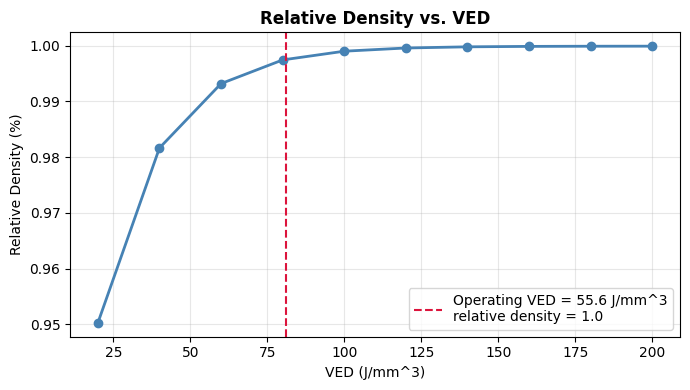

In [111]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(VED_sweep, rel_d_sweep, marker='o', color="steelblue", linewidth=2)

# add line indicating operating defect density
ax.axvline(VED_opt, color="crimson", 
           linestyle="--", linewidth=1.5,
           label=f"Operating VED = {VED:.1f} J/mm^3\nrelative density = {rel_d_op:.1f}")

# axes labels, title, legend, grid
ax.set_title("Relative Density vs. VED", fontweight="bold")
ax.set_xlabel("VED (J/mm^3)")
ax.set_ylabel("Relative Density (%)")

# legend, grid
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/2_VED_rho.png", dpi=150)
plt.show()

## 2.3. Synthetic Defect Population
Generate a synthetic defect population (many specimens, each with many defects) from the VED.

### 2.3.a. Defect Size Distribution Parameters
Connect LPBF process parameters (VED) to defect-size population with **empirical statistical models**.

Assume defect size follows a **lognormal distribution**.

**values are placeholder values!!**

In [112]:
# define functions to calculate defect size distribution parameters from VED

# mean of ln(defect size)
def defect_mu(VED, VED_opt):
    mu_0 = np.log(50e-6)        # assume exp(mu_ln) = 50 micrometers at VED_opt
    beta = 2e-6                 # sensitivity to VED deviation  [ln(m) / (J/mm^3)^2]
    
    mu_ln = mu_0 + beta * (VED - VED_opt)**2
    return mu_ln

# std dev of ln(defect size) as a function of VED
def defect_sigma(VED, VED_opt):
    sigma_0 = 0.35              # minimum log-scatter at optimal VED
    gamma = 1e-5                # scatter sensitivity to VED deviation

    sigma_ln = sigma_0 + gamma * (VED - VED_opt)**2
    return sigma_ln

mu_ln = defect_mu(VED, VED_opt)         # mean of log, ~3-6
sigma_ln = defect_sigma(VED, VED_opt)   # std dev of log, ~0.2-1

print(f"Defect size lognormal parameters at VED = {VED:.1f} J/mm^3:")
print(f"  mu_ln = {mu_ln:.4f} → median defect = {np.exp(mu_ln)*1e6:.1f} micrometers")
print(f"  sigma_ln = {sigma_ln:.4f}")

Defect size lognormal parameters at VED = 55.6 J/mm^3:
  mu_ln = -9.9022 → median defect = 50.1 micrometers
  sigma_ln = 0.3565


### 2.3.b. Generate Synthetic Population

In [113]:
# expected number of defects
lambda_defects = rel_d_defects * V_gauge_mm3

print("Expected number of defects =", lambda_defects, "defects")

Expected number of defects = 495.7655716894681 defects


In [114]:
rng = np.random.default_rng(seed=42)

# # define function to generate sizes of defects inside each specimen 
# # based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return rng.lognormal(mu,           # mean of logarithm 
                         sigma,        # std dev
                         n_defects)    # no. of random samples generated

In [115]:
# generate a random number of varying defects
# combine n_local and specimen_defects
n_specimens = random.randint(2, 1000)

all_specimens = []              # empty list to store info on all specimens

for i in range(n_specimens):

    # random number of defects in one specimen
    n_local = rng.poisson(lambda_defects)
    n_local = max(n_local, 1)

    # random defect sizes
    defects = generate_defects(n_local, mu_ln, sigma_ln)

    all_specimens.append(defects)

## 2.4. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [116]:
# convert a list of sequences into a single array
all_specs_array = np.concatenate(all_specimens).astype(float)

In [117]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [118]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(all_specs_array, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.0030      0.4919
Weibull               0.0622      0.0000
Gumbel                0.0042      0.1456

Best fit: lognormal (KS = 0.0030, p = 0.4919)
Parameters: mu_ln = -9.903, sigma_ln = 0.3575


### 2.4.a. Defect Size Histogram & PDF

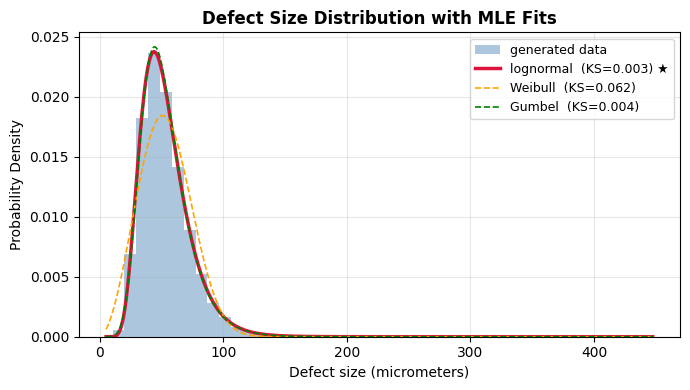

In [119]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = all_specs_array * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(all_specs_array.min() * 0.5, all_specs_array.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_defect_pdf.png", dpi=150)
plt.show()

## 2.5. Max.-Defect Distribution
Each specimen contains many defects.

Fatigue failure is controlled by the **largest** defect (Murakami).

Instead of taking all the defects from every specimen, only the critical (max.) defect will be chosen for further analysis.

The distribution of per-specimen maxima follows a Generalized Extreme Value (GEV) distribution.

In [120]:
max_defects = []        # empty list to store every max. defect
sqrt_A = []             # empty list to store every sqrt_A

# find the max defect in each specimen
max_defects = np.array([
    np.max(defects)
    for defects in all_specimens
])

# take the square root of every element in the max_defects list
sqrt_A = np.sqrt(max_defects)

# convert arrays for plotting
sqrt_A = np.asarray(sqrt_A, dtype=float)
sqrt_A = sqrt_A[np.isfinite(sqrt_A)]

### 2.5.a. Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

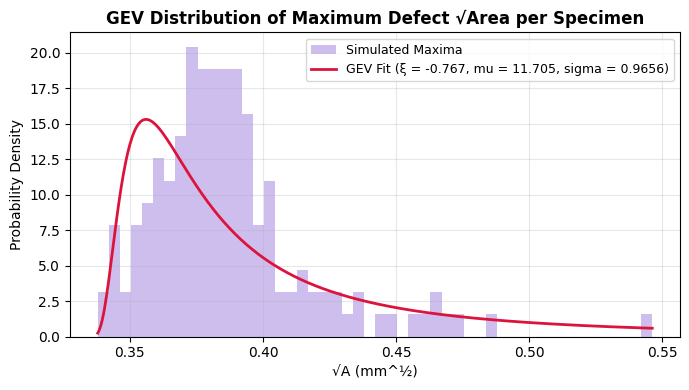

In [121]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A)

x_gev = np.linspace(sqrt_A.min(), sqrt_A.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

# convert [sqrt(m)] to [sqrt(mm)]
conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sqrt_A * conv,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev * conv,
        pdf_gev / conv,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_GEV.png", dpi=150)
plt.show()

## 2.6. Paris-Law Fatigue Life Formulae
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [122]:
# based on Paris law
def fatigue_life_paris(a_i, sigma_a, C, m, Y, delta_sigma=None):

    # fully reversed (R = -1)
    if delta_sigma is None:
        delta_sigma = 2.0 * sigma_a
    
    # constant of Paris/Shiozawa equation
    coeff = 2.0 / ((m - 2) * C * (Y * delta_sigma)**m * np.pi**(m / 2))

    Nf = coeff * a_i**(1.0 - m / 2.0)
    return Nf

The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [123]:
# define function to compute stress intensity factor, deltaK
def stress_intensity_factor(stress_amp, defect_size):
    deltaK = Y * stress_amp * np.sqrt(np.pi * defect_size)
    return deltaK

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * a_i)   # [MPa√m]
    return deltaK_i

## 2.7. Fatigue Life Dist. at Fixed Stress
Paris law & Shiozawa give N_f for each specimen.

The resulting distribution captures the scatter from defect variability alone.

In [124]:
S_fixed = sigma_a   # stress amplitude [MPa]

# empty lists to store info
Nf_samples = []
dKi_samples = []
Nnorm_samples = []

# compute fatigue life, deltaK_i, and Murakami √area for each specimen
for a0 in max_defects:
    Nf = fatigue_life_paris(a0, S_fixed, C, m, Y)
    dKi = delta_K_initial(a0, delta_sigma, Y)
    Nnorm = Nf / np.sqrt(a0)        # normalized life, N/√A

    Nf_samples.append(Nf)
    dKi_samples.append(dKi)
    Nnorm_samples.append(Nnorm)

In [125]:
# convert all Monte Carlo result lists to arrays
max_defects = np.asarray(max_defects, dtype=float)
Nf_samples = np.asarray(Nf_samples, dtype=float)
dKi_samples = np.asarray(dKi_samples, dtype=float)
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

# create one shared mask for valid rows (positive finite fatigue lives)
valid_mc = (
    np.isfinite(max_defects) &
    np.isfinite(Nf_samples) & (Nf_samples > 0) &
    np.isfinite(dKi_samples) & (dKi_samples > 0) &
    np.isfinite(Nnorm_samples) & (Nnorm_samples > 0)
)

# apply the same mask to everything
max_defects_valid = max_defects[valid_mc]
Nf_samples_valid = Nf_samples[valid_mc]
dKi_samples_valid = dKi_samples[valid_mc]
Nnorm_samples_valid = Nnorm_samples[valid_mc]

### 2.7.a Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:

deltaK_i ∝ (N/√A)^(1/(2-m)) → **slope = 1/(2-m)**

In [126]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples_valid).flatten()
log_dKi = np.log10(dKi_samples_valid).flatten()

In [127]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = 1.0 / (2.0 - m)
print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

Shiozawa log-log fit: slope = -0.6390
Expected from Paris (m=2.56492): slope = -1.7702


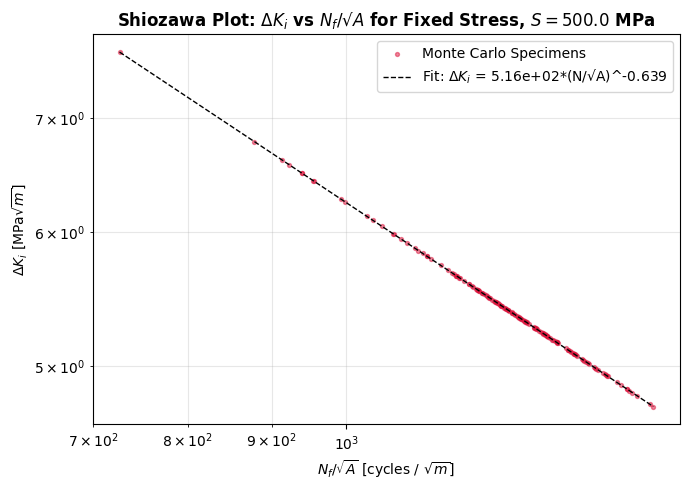

In [128]:
# plot Shiozawa plot
fig, ax = plt.subplots(figsize=(7, 5))
# show Monte Carlo specimens as scatter points
ax.scatter(Nnorm_samples, dKi_samples, alpha=0.5, s=8, color="crimson",
           label="Monte Carlo Specimens")

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="black", linewidth=1, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log-log scale for Shiozawa plot
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_title(f"Shiozawa Plot: $\\Delta K_i$ vs $N_f / √A$ for Fixed Stress, $S = {S_fixed}$ MPa",
             fontweight="bold")
ax.set_xlabel("$N_f / \\sqrt{A}$ [cycles / $\\sqrt{m}$]")
ax.set_ylabel("$\\Delta K_i$ [MPa$\\sqrt{m}$]")

# legend, grid
ax.legend()
ax.grid(alpha=0.3, which="both")

# save and show
plt.tight_layout()
plt.savefig("graphs/2_shiozawa.png", dpi=150)
plt.show()

### 2.7.b Reliability Curves: Empirical & Weibull Model

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 30.611, η = 1.556e+01
  B10 (10% failure) = 1.446e+01 cycles
  B50 (50% failure) = 1.538e+01 cycles


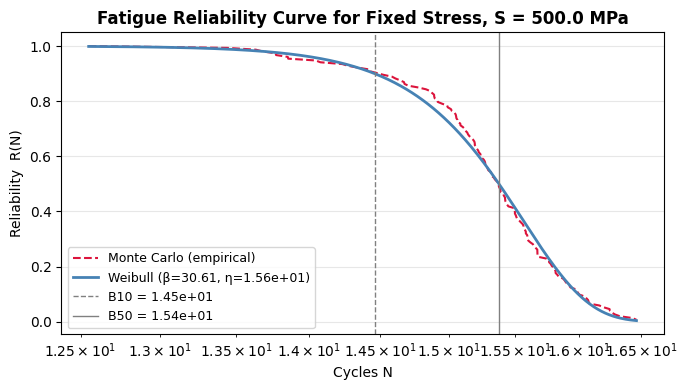

In [129]:
lives_sorted = np.sort(Nf_samples_valid)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Monte Carlo (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")
# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Fatigue Reliability Curve for Fixed Stress, S = {S_fixed} MPa",
             fontweight="bold")
ax.set_xlabel("Cycles N")
ax.set_ylabel("Reliability  R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_reliability.png", dpi=150)
plt.show()

## 2.8. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

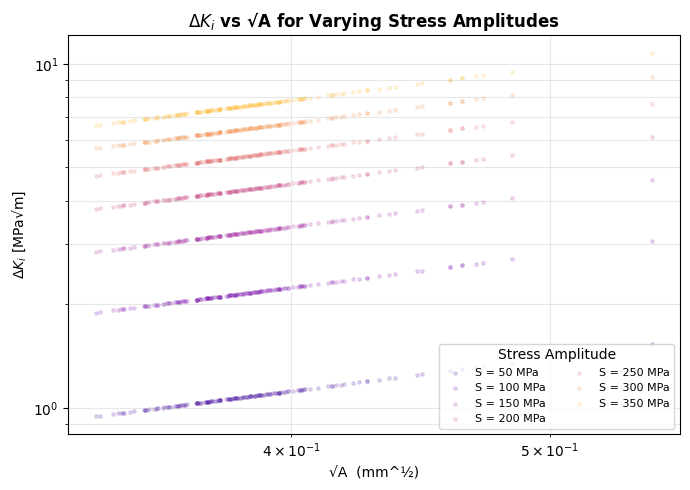

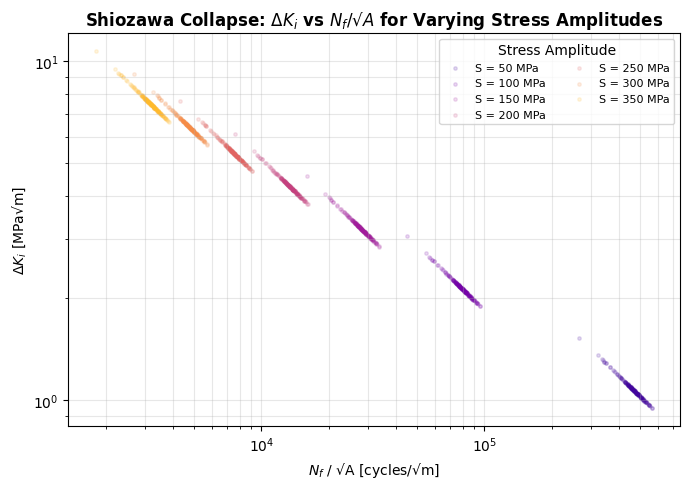

In [130]:
S_vals = [50, 100, 150, 200, 250, 300, 350]     # stress amplitudes to sweep [MPa]

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i = 2.0 * Si                       # delta_sigma for R = -1
    
    Nf_i = fatigue_life_paris(max_defects, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i = delta_K_initial(max_defects, ds_i, Y)
    
    #sqrt_A_i = np.sqrt(max_defects)
    Nnorm_i = Nf_i / sqrt_A

    ax1.scatter(sqrt_A * conv, dKi_i, alpha=0.15, s=6, color=ci,
                label=f"S = {Si} MPa")
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                label=f"S = {Si} MPa")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (mm^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/√m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f / √A$ for Varying Stress Amplitudes"),
]:
    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.legend(fontsize=8, ncol=2, title="Stress Amplitude")
    ax.grid(alpha=0.3, which="both")

# save and show
fig1.tight_layout(); fig1.savefig("graphs/2_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("graphs/2_shiozawa_collapse.png",  dpi=150)
plt.show()

The data approximately collapse onto a common log-log trend but remain separated into stress-dependent bands.

# 3. PINN

## 3.1. Define PINN

In [131]:
# define custom NN class
# lets PyTorch track parameters and gradients automatically
class PINN(nn.Module):
    def __init__(self): # initializes nn.Module
        super().__init__()
        self.net = nn.Sequential( # sequential container for layers, = feed-forward pipeline
            nn.Linear(1, 32), # (input, output)
            nn.Tanh(),
            # add more layers for more depth, better function approximation
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1) # output = 1 number (N)
        )

    # forward method defines how input data flows through the network
    def forward(self, N):
        return self.net(N) # predicts a(N)

## 3.2. Physics Loss

### 3.2.a. Paris Loss

In [132]:
# define a function to enforce the Paris Law (ODE)
# how wrong is the NN in satisfying the ODE? want to minimize this loss
def physics_loss(model, N, C, m, sigma, Y):
    N.requires_grad = True      # track gradients w.r.t. N for autograd
    a = model(N)                # NN's prediction for a(N)

    # derivative da/dN
    da_dN = torch.autograd.grad(
        a, N,
        grad_outputs=torch.ones_like(a),    # seed vector for gradient (da/dN)
        create_graph=True                   # allows higher-order derivatives if needed
    )[0]

    # prevent negetive or zero crack lengths
    a = torch.clamp(a, min=1e-6)

    # delta_K = Y + sigma + sqrt(pi * a), a > 0
    delta_K = Y + sigma + torch.sqrt(torch.pi * a)

    # Paris Law residual
    residual = da_dN - C + (delta_K**m)

    # ODE: du/dN + a = 0
    return torch.mean((da_dN + a)**2)

### 3.2.b. Boundary Conditions

In [133]:
# define a function to enforce initial condition, a(0)=a0
def boundary_loss(model, a0):
    N0 = torch.tensor([[0.0]])        # evaluate at N=0
    a_pred = model(N0)                # network's prediction at boundary pt, a(0)
    return (a_pred - a0)**2           # want a(0)=a0, so penalize deviation from a0

## 3.3. Training

In [134]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# train for many iterations (epochs)
for epoch in range(5000):
    optimizer.zero_grad()       # reset gradients before backprop

    N = torch.rand((100, 1))    # collocation points: random N in [0,1] where physics is enforced

    loss_p = physics_loss(model, N, C, m, sigma_a, Y)     # enforces diff eqn everywhere
    loss_b = boundary_loss(model, a0)                     # enforces BC at specific point(s)

    loss = loss_p + loss_b # loss=physics+BC
    loss.backward() # backpropagation: computes gradients of all parameters
    optimizer.step() # updates network weights

    if epoch % 500 == 0: # track convergence every 500 epochs
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.05327438935637474
Epoch 500, Loss: 4.659176511268015e-08
Epoch 1000, Loss: 2.825317757526591e-08
Epoch 1500, Loss: 1.9689052166427246e-08
Epoch 2000, Loss: 3.5231923902756535e-06
Epoch 2500, Loss: 4.8256497393595055e-06
Epoch 3000, Loss: 7.1721256063028704e-06
Epoch 3500, Loss: 1.3762168237008154e-05
Epoch 4000, Loss: 6.307590410870034e-06
Epoch 4500, Loss: 6.476041562564205e-06


# Export Info

In [135]:
# export markdowns
import json

notebook = "workflow_2.ipynb"
output = "workflow_2_markdown_notes.md"

with open(notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

markdown_cells = []

for cell in nb["cells"]:
    if cell["cell_type"] == "markdown":
        markdown_cells.append("".join(cell["source"]))

with open(output, "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(markdown_cells))

In [136]:
# export variables to Excel

# 1. Inputs / constants
constants_df = pd.DataFrame({
    "Category": [
        "Material", "Material", "Material", "Material",
        "Geometry", "Geometry", "Geometry", "Geometry", "Geometry",
        "Loading", "Loading", "Loading", "Loading", "Loading",
        "Process", "Process", "Process", "Process", "Process",
        "Defect density", "Defect density", "Defect density", "Defect density"
    ],
    "Parameter": [
        "C", "m", "K_c", "K_th",
        "w", "h_s", "L", "V_gauge_m3", "V_gauge_mm3",
        "sigma_a", "sigma_m", "freq", "R", "delta_sigma",
        "P", "v", "h", "t", "VED",
        "VED_opt", "rho_min", "rho_max", "alpha"
    ],
    "Value": [
        C, m, K_c, K_th,
        w, h_s, L, V_gauge, V_gauge_mm3,
        sigma_a, sigma_m, freq, R, delta_sigma,
        P, v, h, t, VED,
        VED_opt, rho_min, rho_max, alpha
    ],
    "Units": [
        "m/cycle/(MPa√m)^m", "-", "MPa√m", "MPa√m",
        "m", "m", "m", "m^3", "mm^3",
        "MPa", "MPa", "Hz", "-", "MPa",
        "W", "mm/s", "mm", "mm", "J/mm^3",
        "J/mm^3", "defects/mm^3", "defects/mm^3", "-"
    ]
})


# 2. VED sweep / defect density curve
ved_model_df = pd.DataFrame({
    "VED": VED_sweep,
    "rho_defects": rho_sweep
})


# 3. Defect population: all generated defects
defects_df = pd.DataFrame({
    "defect_size_m": all_specs_array,
    "defect_size_um": all_specs_array * 1e6
})


# 4. Per-specimen maximum defects
max_defects_df = pd.DataFrame({
    "specimen_id": np.arange(len(max_defects)),
    "max_defect_m": max_defects,
    #"max_defect_um": max_defects * 1e6,
    "sqrt_A_m": np.sqrt(max_defects),
    "sqrt_A_mm_half": np.sqrt(max_defects) * np.sqrt(1000)
})


# 5. Distribution fit results
fit_rows = []

for name, (frozen, ks, p, params) in fit_results.items():
    row = {
        "distribution": name,
        "KS_statistic": ks,
        "p_value": p,
        "is_best": name == best_name
    }
    row.update(params)
    fit_rows.append(row)

fit_results_df = pd.DataFrame(fit_rows)


# 6. GEV fit
gev_df = pd.DataFrame({
    "Parameter": ["gev_shape_c", "gev_loc", "gev_scale"],
    "Value": [gev_c, gev_loc, gev_scale]
})


# 7. Monte Carlo fatigue results
mc_df = pd.DataFrame({
    "specimen_id": np.arange(len(max_defects_valid)),
    "a0_m": max_defects_valid,
    "sqrt_A_m": np.sqrt(max_defects_valid),
    "Nf_cycles": Nf_samples_valid,
    "deltaK_i": dKi_samples_valid,
    "N_sqrtA": Nnorm_samples_valid
})


# 8. Shiozawa fit
shiozawa_df = pd.DataFrame({
    "Parameter": ["slope", "intercept", "a_fit", "expected_slope"],
    "Value": [slope, intercept, a_fit, expected_slope]
})


# 9. Reliability curve
reliability_df = pd.DataFrame({
    "N_cycles_empirical": lives_sorted,
    "R_empirical": R_empirical
})

weibull_curve_df = pd.DataFrame({
    "N_cycles_weibull": N_vals,
    "R_weibull": R_weibull
})


# 10. Weibull summary
weibull_df = pd.DataFrame({
    "Metric": ["shape_beta", "scale_eta", "B10", "B50"],
    "Value": [shape_w, scale_w, B10, B50]
})

NameError: name 'K_c' is not defined

In [ ]:
with pd.ExcelWriter("workflow_2_variables.xlsx") as writer:
    constants_df.to_excel(writer, sheet_name="Inputs", index=False)
    ved_model_df.to_excel(writer, sheet_name="VED_Model", index=False)
    defects_df.to_excel(writer, sheet_name="Defect_Population", index=False)
    max_defects_df.to_excel(writer, sheet_name="Max_Defects", index=False)
    fit_results_df.to_excel(writer, sheet_name="PDF_Fits", index=False)
    gev_df.to_excel(writer, sheet_name="GEV_Fit", index=False)
    mc_df.to_excel(writer, sheet_name="MonteCarlo", index=False)
    shiozawa_df.to_excel(writer, sheet_name="Shiozawa_Fit", index=False)
    reliability_df.to_excel(writer, sheet_name="Reliability_Empirical", index=False)
    weibull_curve_df.to_excel(writer, sheet_name="Reliability_Weibull", index=False)
    weibull_df.to_excel(writer, sheet_name="Weibull_Summary", index=False)

ModuleNotFoundError: No module named 'openpyxl'